# Sustainability Aware Asset Management
## Portfolio Allocation with Carbon Objective : Europe Scope 1 & 2
### Final Project Notebook - Group BO

#### Authors: Hary Andrianjafy, Alessandra Failla, Isaure Lunven, Anna Modolo

#### Date: 29 May, 2026

## 1. Methodology

#### 1.1 Loading and Cleaning the data 

In [29]:
!pip install pandas openpyxl matplotlib scipy 

In [30]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os

In [41]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"

RAW_DIR = DATA_DIR / "data_raw"
CLEAN_DIR = DATA_DIR / "data_clean"

RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory verified at: {BASE_DIR}")
print("Arborescence check: 'data/data_raw' and 'data/data_clean' are ready.")

Project directory verified at: /Users/alessandra/SAAM_Group_BO
Arborescence check: 'data/data_raw' and 'data/data_clean' are ready.


In [44]:
import sys
import shutil

# 1. Enforce dynamic root path discovery (No hardcoded local paths)
BASE_DIR = Path.cwd()

# Définition du dossier principal 'data'
DATA_DIR = BASE_DIR / "data"

# Définition des sous-dossiers à l'intérieur de 'data'
RAW_DIR = DATA_DIR / "data_raw"
CLEAN_DIR = DATA_DIR / "data_clean"

# Automatically create directories if they are missing (parents=True crée aussi 'data')
RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# 2. Exact inventory of your 9 sustainability & asset management CSV files
PROJECT_DATASETS = [
    "Risk_Free_Rate_2025.xlsx",
    "DS_CO2_SCOPE_1_Y_2025.xlsx",
    "DS_CO2_SCOPE_2_Y_2025.xlsx",
    "DS_REV_Y_2025.xlsx",
    "DS_RI_T_USD_Y_2025.xlsx",
    "DS_MV_T_USD_M_2025.xlsx",
    "DS_RI_T_USD_M_2025.xlsx",
    "DS_MV_T_USD_Y_2025.xlsx",
    "Static_2025.xlsx"
]
print("AUTOMATING PORTFOLIO DATA PIPELINE SETUP")

missing_files = []

for file_name in PROJECT_DATASETS:
    root_location = BASE_DIR / file_name
    target_location = RAW_DIR / file_name
    
    # Scenario A: File is at the root directory -> Move it automatically
    if root_location.exists():
        shutil.move(str(root_location), str(target_location))
        print(f" Moved: {file_name} ➔ data/data_raw/")
        
    # Scenario B: File is already safely inside data/data_raw/ -> Pass quietly
    elif target_location.exists():
        print(f" Verified: {file_name} is already in data/data_raw/")
        
    # Scenario C: File cannot be found anywhere -> Flag it
    else:
        print(f" Missing: {file_name} was not found!")
        missing_files.append(file_name)

print("----------------------------------------------------")
if missing_files:
    print(f"Warning: {len(missing_files)} files are missing from the project folder.")
    print("Please make sure all downloaded files are directly inside this project folder.")
else:
    print("Execution pipeline fully automated!")

AUTOMATING PORTFOLIO DATA PIPELINE SETUP
 Moved: Risk_Free_Rate_2025.xlsx ➔ data/data_raw/
 Moved: DS_CO2_SCOPE_1_Y_2025.xlsx ➔ data/data_raw/
 Moved: DS_CO2_SCOPE_2_Y_2025.xlsx ➔ data/data_raw/
 Moved: DS_REV_Y_2025.xlsx ➔ data/data_raw/
 Moved: DS_RI_T_USD_Y_2025.xlsx ➔ data/data_raw/
 Moved: DS_MV_T_USD_M_2025.xlsx ➔ data/data_raw/
 Moved: DS_RI_T_USD_M_2025.xlsx ➔ data/data_raw/
 Moved: DS_MV_T_USD_Y_2025.xlsx ➔ data/data_raw/
 Moved: Static_2025.xlsx ➔ data/data_raw/
----------------------------------------------------
Execution pipeline fully automated!


In [47]:
# Load scope1
scope1 = pd.read_excel(RAW_DIR / "DS_CO2_SCOPE_1_Y_2025.xlsx")
scope1 = scope1.dropna(subset=["ISIN"])
scope1 = scope1.replace("$$ER: E100,INVALID CODE OR EXPRESSION ENTERED", pd.NA)
scope1 = scope1.replace("$$ER: 0904,NO DATA AVAILABLE", pd.NA)
scope1 = scope1.drop(columns=[2025], errors="ignore")
year_cols = scope1.columns[2:]
scope1[year_cols] = scope1[year_cols].apply(pd.to_numeric, errors="coerce")
scope1[year_cols] = scope1[year_cols].T.ffill().T
scope1 = scope1.dropna(subset=year_cols, how="all")
scope1.to_excel(CLEAN_DIR / "scope1_clean.xlsx", index=False)
print("scope1:", scope1.shape)

scope1: (2394, 28)


In [48]:
# Load scope2
scope2 = pd.read_excel(RAW_DIR / "DS_CO2_SCOPE_2_Y_2025.xlsx")
scope2 = scope2.dropna(subset=["ISIN"])
scope2 = scope2.replace("$$ER: E100,INVALID CODE OR EXPRESSION ENTERED", pd.NA)
scope2 = scope2.replace("$$ER: 0904,NO DATA AVAILABLE", pd.NA)
scope2 = scope2.drop(columns=[2025], errors="ignore")
year_cols = scope2.columns[2:]
scope2[year_cols] = scope2[year_cols].apply(pd.to_numeric, errors="coerce")
scope2[year_cols] = scope2[year_cols].T.ffill().T
scope2 = scope2.dropna(subset=year_cols, how="all")
scope2.to_excel(CLEAN_DIR / "scope2_clean.xlsx", index=False)
print("scope2:", scope2.shape)

scope2: (2396, 28)


In [49]:
# Load revenues (divide by 1000 to convert thousands USD -> millions USD)
revenues = pd.read_excel(RAW_DIR / "DS_REV_Y_2025.xlsx")
revenues = revenues.dropna(subset=["ISIN"])
year_cols = revenues.columns[2:]
revenues[year_cols] = revenues[year_cols].apply(pd.to_numeric, errors="coerce")
revenues[year_cols] = revenues[year_cols].T.ffill().T
revenues = revenues.dropna(subset=year_cols, how="all")
revenues[year_cols] = revenues[year_cols] / 1000  # now in millions USD
revenues.to_excel(CLEAN_DIR / "revenues_clean.xlsx", index=False)
print("revenues:", revenues.shape)

revenues: (2528, 29)


In [50]:
# Load annual market cap
mv_year = pd.read_excel(RAW_DIR / "DS_MV_T_USD_Y_2025.xlsx")
mv_year = mv_year.dropna(subset=["ISIN"])
year_cols = mv_year.columns[2:]
mv_year[year_cols] = mv_year[year_cols].apply(pd.to_numeric, errors="coerce")
mv_year[year_cols] = mv_year[year_cols].T.ffill().T
mv_year = mv_year.dropna(subset=year_cols, how="all")
mv_year.to_excel(CLEAN_DIR / "market_value_year_clean.xlsx", index=False)
print("mv_year:", mv_year.shape)

mv_year: (2542, 29)


In [51]:
# Load monthly market cap
mv_month = pd.read_excel(RAW_DIR / "DS_MV_T_USD_M_2025.xlsx")
mv_month = mv_month.dropna(subset=["ISIN"])
mv_cols = mv_month.columns[2:]
mv_month[mv_cols] = mv_month[mv_cols].apply(pd.to_numeric, errors="coerce")
mv_month.to_excel(CLEAN_DIR / "market_value_month_clean.xlsx", index=False)
print("mv_month:", mv_month.shape)

mv_month: (2545, 316)


In [52]:
# Load monthly prices
prices = pd.read_excel(RAW_DIR / "DS_RI_T_USD_M_2025.xlsx")
prices = prices.dropna(subset=["ISIN"]).copy()
price_cols = prices.columns[2:]

# Force numeric
prices[price_cols] = prices[price_cols].apply(pd.to_numeric, errors="coerce")

# Treat prices below 0.5 as missing
prices[price_cols] = prices[price_cols].mask(prices[price_cols] < 0.5)

prices.head()

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
1,SLB,AN8068571086,1708.01,1858.26,2254.15,2334.75,2336.65,2245.09,2283.70,2262.67,...,3270.81,3251.13,3353.42,3353.42,3655.03,3437.74,3606.77,3624.78,3867.96,4875.77
2,ALUAR,ARALUA010258,1547.04,1820.11,1911.12,1866.11,1835.93,1805.22,1657.42,1911.95,...,3095.40,3702.96,3344.23,3256.09,3037.93,2793.77,3782.29,4021.72,3812.33,4041.31
3,BANCO BBVA ARGENTINA,ARP125991090,418.23,396.54,467.49,418.37,350.66,352.52,401.75,404.48,...,993.48,952.87,805.06,775.54,607.67,452.86,840.33,834.27,938.53,1039.75
4,TERNIUM ARGENTINA SOCIEDAD ANONIMA,ARSIDE010029,178.40,177.53,184.55,184.16,171.05,112.65,120.55,124.93,...,587.94,663.26,588.27,590.42,490.39,476.31,568.86,630.98,527.52,552.86
5,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.27,430.83,479.46,477.35,465.06,461.50,396.65,452.87,481.49,526.88


In [54]:
# Load Risk-free rate
rf_raw = pd.read_excel(RAW_DIR / "Risk_Free_Rate_2025.xlsx")

# Rename date column to "Date"
rf_raw.rename(columns={rf_raw.columns[0]: 'Date'}, inplace=True)

# 2. Convert the "Date" column to date format 
rf_raw['Date'] = pd.to_datetime(rf_raw['Date'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)

# 3. Convert the "RF" column to decimal format (divide by 100)
rf_raw['RF_dec'] = rf_raw['RF'] / 100

# 4. Set the date as the index
rf_clean = rf_raw.set_index('Date')['RF_dec']
rf_clean.to_excel(CLEAN_DIR / "risk_free_rate_clean.xlsx")
print("risk-free rate:", rf_clean.shape)
print(rf_clean.head())

risk-free rate: (312,)
Date
2000-01-31    0.0041
2000-02-29    0.0043
2000-03-31    0.0047
2000-04-30    0.0046
2000-05-31    0.0050
Name: RF_dec, dtype: float64


In [55]:
# Compute simple returns and handle delisting
returns = prices[["NAME", "ISIN"]].copy()
returns[price_cols] = np.nan

for idx in prices.index:
    p = prices.loc[idx, price_cols]

    # simple returns, no forward-filling of prices
    r = p.pct_change(fill_method=None)

    # find the last valid price position
    valid_positions = p.notna()
    if valid_positions.any():
        last_valid_pos = valid_positions.values.nonzero()[0][-1]
        after_last = p.iloc[last_valid_pos + 1:]
        # if everything after last valid price is NaN -> delisted
        if len(after_last) > 0 and after_last.isna().all():
            r.iloc[last_valid_pos + 1] = -1.0
            # rest stay NaN

    returns.loc[idx, price_cols] = r.values

returns.to_excel(CLEAN_DIR / "returns_monthly_clean.xlsx", index=False)
print("returns:", returns.shape)
returns.head()

/var/folders/5l/zzd3ggf17h7gf_ttl9s5bmww0000gn/T/ipykernel_23868/2451703389.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[price_cols] = np.nan


returns: (2545, 316)


,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
1,SLB,AN8068571086,NaN,0.087968,0.213043,0.035756,0.000814,-0.039184,0.017198,-0.009209,...,-0.204544,-0.006017,0.031463,0.000000,0.089941,-0.059450,0.049169,0.004993,0.067088,0.260553
2,ALUAR,ARALUA010258,NaN,0.176511,0.050002,-0.023552,-0.016173,-0.016727,-0.081874,0.153570,...,-0.320818,0.196278,-0.096877,-0.026356,-0.067001,-0.080371,0.353830,0.063303,-0.052065,0.060063
3,BANCO BBVA ARGENTINA,ARP125991090,NaN,-0.051861,0.178923,-0.105072,-0.161842,0.005304,0.139652,0.006795,...,-0.071956,-0.040877,-0.155121,-0.036668,-0.216456,-0.254760,0.855607,-0.007211,0.124972,0.107850
4,TERNIUM ARGENTINA SOCIEDAD ANONIMA,ARSIDE010029,NaN,-0.004877,0.039543,-0.002113,-0.071188,-0.341421,0.070129,0.036333,...,-0.321595,0.128108,-0.113063,0.003655,-0.169422,-0.028712,0.194306,0.109201,-0.163967,0.048036
5,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270


#### 1.2 Building the Investment Universe 
Build the Europe investment universe using firms that are present in returns, emissions, revenues, and market value datasets.

In [56]:
# Load all cleaned data
returns_raw    = pd.read_excel(CLEAN_DIR / "returns_monthly_clean.xlsx")
scope1_clean   = pd.read_excel(CLEAN_DIR / "scope1_clean.xlsx")
scope2_clean   = pd.read_excel(CLEAN_DIR / "scope2_clean.xlsx")
revenues_clean = pd.read_excel(CLEAN_DIR / "revenues_clean.xlsx")
mv_year_clean  = pd.read_excel(CLEAN_DIR / "market_value_year_clean.xlsx")
mv_month_clean = pd.read_excel(CLEAN_DIR / "market_value_month_clean.xlsx")
static         = pd.read_excel(RAW_DIR / "Static_2025.xlsx")
rf_clean      = pd.read_excel(CLEAN_DIR / "risk_free_rate_clean.xlsx")

print("returns_raw:", returns_raw.shape)

returns_raw: (2545, 316)


In [57]:
# Filter to Europe only
static_europe = static[static["Region"].str.upper() == "EUR"].copy()
isins_europe = set(static_europe["ISIN"])
print("European firms:", len(isins_europe))

European firms: 633


In [58]:
# Build returns matrix (firms x months), indexed by ISIN
returns_matrix = returns_raw[returns_raw["ISIN"].isin(isins_europe)].copy()
returns_matrix = returns_matrix.set_index("ISIN").drop(columns=["NAME"])
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix = returns_matrix.sort_index(axis=1)
print("returns_matrix:", returns_matrix.shape)

returns_matrix: (633, 314)


## 2. Part I: Standard Portfolio Allocation

#### 2.1 Minimum-Variance Portfolio

In [59]:
# Pre-compute emissions and e_over_cap for all years outside the loop
scope1_nb2   = pd.read_excel(CLEAN_DIR / "scope1_clean.xlsx").set_index("ISIN").drop(columns=["NAME"], errors="ignore")
scope2_nb2   = pd.read_excel(CLEAN_DIR / "scope2_clean.xlsx").set_index("ISIN").drop(columns=["NAME"], errors="ignore")
mv_year_nb2  = pd.read_excel(CLEAN_DIR / "market_value_year_clean.xlsx").set_index("ISIN").drop(columns=["NAME"], errors="ignore")

scope1_nb2.columns   = scope1_nb2.columns.astype(int)
scope2_nb2.columns   = scope2_nb2.columns.astype(int)
mv_year_nb2.columns  = mv_year_nb2.columns.astype(int)

emissions_nb2 = scope1_nb2.add(scope2_nb2, fill_value=0)

e_over_cap_all = {}
for year in range(2013, 2025):
    if year in emissions_nb2.columns and year in mv_year_nb2.columns:
        e_over_cap_all[year] = emissions_nb2[year].div(mv_year_nb2[year].replace(0, np.nan))

# Setup
start_year = 2013
end_year   = 2024
window     = 120

all_weights          = {}
mv_portfolio_returns = []
mv_dates             = []

isins_scope1 = set(scope1_clean["ISIN"])
isins_scope2 = set(scope2_clean["ISIN"])
has_carbon_global = pd.Series(
    returns_matrix.index.isin(isins_scope1 | isins_scope2),
    index=returns_matrix.index
)

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue

    past_ret = returns_matrix[past_cols]

    # Filter (a): at least 36 non-NaN observations
    enough_obs = past_ret.notna().sum(axis=1) >= 36

    # Filter (b): stale price filter
    non_nan_count = past_ret.notna().sum(axis=1).replace(0, np.nan)
    zero_count    = (past_ret == 0).sum(axis=1)
    not_stale     = (zero_count / non_nan_count) <= 0.5

    # Filter (c): valid price at end of year Y
    has_price = past_ret[past_cols[-1]].notna()

    # Filter (d): carbon data available
    has_carbon = has_carbon_global

    # Combine filters (a)-(d)
    valid       = enough_obs & not_stale & has_price & has_carbon
    valid_isins = valid[valid].index.tolist()

    # Filter (e): exclude firms with E/Cap ratio above 3x the VW carbon footprint
    if year in e_over_cap_all:
        e_over_cap_y = e_over_cap_all[year]
        cap_year_vw  = mv_year_nb2[year].dropna()
        e_year_vw    = emissions_nb2[year].dropna()
        common_vw    = cap_year_vw.index.intersection(e_year_vw.index)
        if len(common_vw) > 0:
            cf_vw_year = e_year_vw[common_vw].sum() / cap_year_vw[common_vw].sum()
            threshold  = 3 * cf_vw_year
        else:
            threshold  = e_over_cap_y.quantile(0.95)
        e_valid     = e_over_cap_y.reindex(valid_isins).dropna()
        valid_isins = [i for i in valid_isins if
                       i not in e_valid.index or e_over_cap_y.get(i, 0) <= threshold]

    if len(valid_isins) < 10:
        print(f"Year {year}: too few valid firms ({len(valid_isins)}), skipping")
        continue

    print(f"Year {year}: {len(valid_isins)} firms in investment set")

    sub        = past_ret.loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    def portfolio_variance(w):
        return w @ Sigma @ w

    def portfolio_variance_grad(w):
        return 2 * Sigma @ w

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                    'jac': lambda w: np.ones(N)}]
    bounds = [(0, 0.05)] * N
    w0     = np.ones(N) / N

    result = minimize(
        portfolio_variance, w0,
        jac=portfolio_variance_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    all_weights[year] = pd.Series(w, index=valid_isins)

    # Next-year monthly returns with weight drift
    next_cols = returns_matrix.columns[
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]

    if len(next_cols) == 0:
        continue

    next_ret  = returns_matrix.loc[valid_isins, next_cols].fillna(0).values
    w_current = w.copy()

    for k in range(next_ret.shape[1]):
        r_t       = next_ret[:, k]
        rp_t      = float(w_current @ r_t)
        mv_portfolio_returns.append(rp_t)
        mv_dates.append(next_cols[k])
        w_current = w_current * (1 + r_t)
        total     = w_current.sum()
        if total > 0:
            w_current = w_current / total

mv_returns = pd.Series(mv_portfolio_returns, index=mv_dates).sort_index()
print(f"\nMV portfolio returns shape: {mv_returns.shape}")
mv_returns.head()

Year 2013: 574 firms in investment set
Year 2014: 577 firms in investment set
Year 2015: 571 firms in investment set
Year 2016: 577 firms in investment set
Year 2017: 573 firms in investment set
Year 2018: 576 firms in investment set
Year 2019: 569 firms in investment set
Year 2020: 561 firms in investment set
Year 2021: 560 firms in investment set
Year 2022: 544 firms in investment set
Year 2023: 533 firms in investment set
Year 2024: 513 firms in investment set

MV portfolio returns shape: (144,)


2014-01-31   -0.006750
2014-02-28    0.053969
2014-03-31   -0.020912
2014-04-30    0.014007
2014-05-30    0.006335
dtype: float64

In [60]:
# Compute the average risk-free rate over the sample period (2014-01-31 to 2025-12-31)
rf_all = pd.read_excel(CLEAN_DIR / "Risk_free_rate_clean.xlsx", index_col='Date', parse_dates=True)
rf_sample_series = rf_all.iloc[:, 0].reindex(mv_returns.index)
rf_monthly = rf_sample_series.mean()

print(f"rf_monthly: {rf_monthly:.6f}")

mean_monthly = mv_returns.mean()
vol_monthly  = mv_returns.std()

mean_annual = mean_monthly * 12
vol_annual  = vol_monthly * np.sqrt(12)


sharpe_mv = ((mv_returns - rf_monthly).mean() / vol_monthly) * np.sqrt(12)

print("=== Minimum Variance Portfolio (OOS) ===")
print(f"Annualized return:     {mean_annual:.4f}")
print(f"Annualized volatility: {vol_annual:.4f}")
print(f"Sharpe ratio:          {sharpe_mv:.4f}")
print(f"Min monthly return:    {mv_returns.min():.4f}")
print(f"Max monthly return:    {mv_returns.max():.4f}")

rf_monthly: 0.001462
=== Minimum Variance Portfolio (OOS) ===
Annualized return:     0.0646
Annualized volatility: 0.1290
Sharpe ratio:          0.3645
Min monthly return:    -0.1209
Max monthly return:    0.1335


#### 2.2 Comparison with Value-Weighted Portfolio

In [61]:
# Build mv_matrix (monthly caps), filter to Europe
mv_matrix = mv_month_clean[mv_month_clean["ISIN"].isin(isins_europe)].copy()
mv_matrix = mv_matrix.set_index("ISIN").drop(columns=["NAME"])
mv_matrix.columns = pd.to_datetime(mv_matrix.columns)
mv_matrix = mv_matrix.sort_index(axis=1)

# Align firms and dates with returns_matrix
common_isins_vw = returns_matrix.index.intersection(mv_matrix.index)
common_dates_vw = returns_matrix.columns.intersection(mv_matrix.columns)

ret_aligned = returns_matrix.loc[common_isins_vw, common_dates_vw].sort_index(axis=1)
mv_aligned  = mv_matrix.loc[common_isins_vw, common_dates_vw].sort_index(axis=1)

# Restrict to OOS period: 2014 onwards
oos_start = pd.Timestamp("2014-01-01")
oos_dates = ret_aligned.columns[ret_aligned.columns >= oos_start]

vw_returns_list = []
vw_dates_list   = []

dates_list = list(oos_dates)
for j in range(1, len(dates_list)):
    prev_t = dates_list[j - 1]
    t      = dates_list[j]

    caps = mv_aligned[prev_t]
    rets = ret_aligned[t]

    valid = caps.notna() & rets.notna() & (caps > 0)
    if valid.sum() == 0:
        continue

    weights = caps[valid] / caps[valid].sum()
    r_vw = (weights * rets[valid]).sum()

    vw_returns_list.append(r_vw)
    vw_dates_list.append(t)

vw_returns = pd.Series(vw_returns_list, index=vw_dates_list).sort_index()
print("VW portfolio returns shape:", vw_returns.shape)
vw_returns.head()

VW portfolio returns shape: (144,)


2014-02-28    0.071072
2014-03-31   -0.006705
2014-04-30    0.018054
2014-05-30    0.012033
2014-06-30   -0.004619
dtype: float64

In [62]:
vw_mean_monthly = vw_returns.mean()
vw_vol_monthly  = vw_returns.std()

vw_mean_annual = vw_mean_monthly * 12
vw_vol_annual  = vw_vol_monthly * np.sqrt(12)

sharpe_vw = ((vw_returns - rf_monthly).mean() / vw_vol_monthly) * np.sqrt(12)

print("=== Value-Weighted Portfolio ===")
print(f"Annualized return:     {vw_mean_annual:.4f}")
print(f"Annualized volatility: {vw_vol_annual:.4f}")
print(f"Sharpe ratio:          {sharpe_vw:.4f}")
print(f"Min monthly return:    {vw_returns.min():.4f}")
print(f"Max monthly return:    {vw_returns.max():.4f}")

=== Value-Weighted Portfolio ===
Annualized return:     0.0883
Annualized volatility: 0.1584
Sharpe ratio:          0.4471
Min monthly return:    -0.1536
Max monthly return:    0.1822


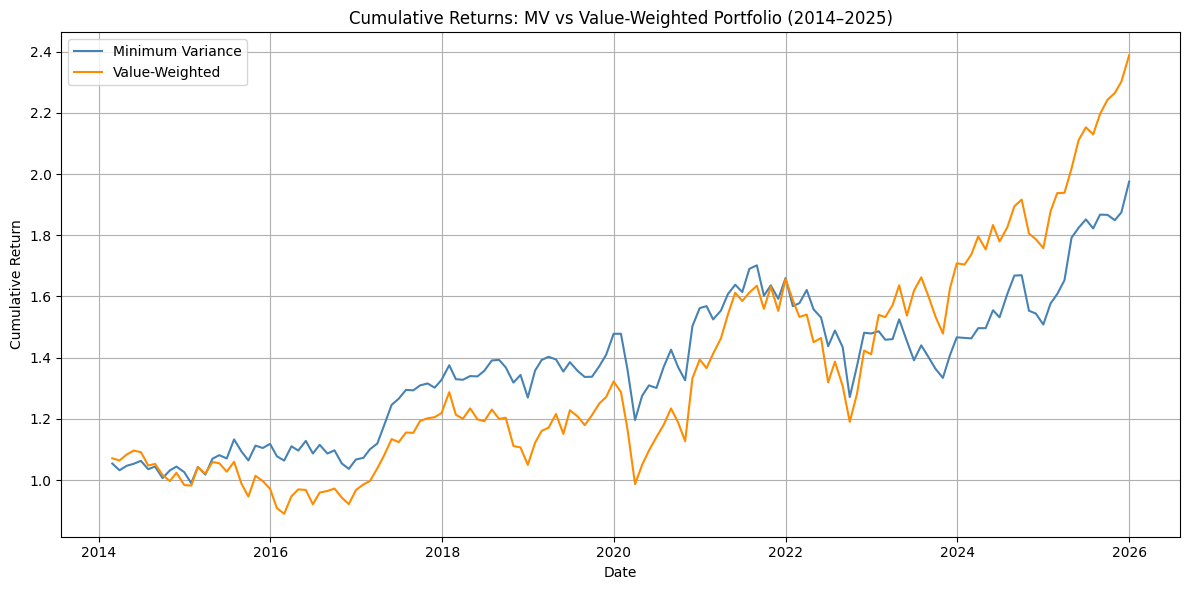


MV Sharpe:  0.3645
VW Sharpe:  0.4471


In [63]:
# Align to common out-of-sample (OOS) dates
common_oos = mv_returns.index.intersection(vw_returns.index)
mv_oos = mv_returns.loc[common_oos]
vw_oos = vw_returns.loc[common_oos]

cum_mv = (1 + mv_oos).cumprod()
cum_vw = (1 + vw_oos).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_mv.index, cum_mv.values, label="Minimum Variance", color="steelblue")
plt.plot(cum_vw.index, cum_vw.values, label="Value-Weighted",   color="darkorange")
plt.title("Cumulative Returns: MV vs Value-Weighted Portfolio (2014–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMV Sharpe:  {sharpe_mv:.4f}")
print(f"VW Sharpe:  {sharpe_vw:.4f}")

In [64]:
# Save base portfolio returns 
mv_returns.to_excel(CLEAN_DIR / "mv_returns.xlsx", header=["MV_Returns"])
vw_returns.to_excel(CLEAN_DIR / "vw_returns.xlsx", header=["VW_Returns"])
print("Base returns saved.")

Base returns saved.


## 3. Part II: Portfolio Allocation with Carbon Emission Reduction

#### 3.1 Carbon Metrics
This section computes and analyzes the carbon metrics of the portfolios
constructed in Part I. We consider Scope 1 + Scope 2 CO2
emissions for all firms in the European investment universe.

We compute:
- **Carbon Intensity (CI)**: tonnes of CO2 per million USD of revenue
- **Weighted Average Carbon Intensity (WACI)**: portfolio-level CI weighted by portfolio weights
- **Carbon Footprint (CF)**: annual CO2 emissions attributed to the investor per million USD invested

All carbon data is annual. The allocation is based on information available
at the end of year Y, applied to year Y+1.

In [65]:
returns_raw = pd.read_excel(CLEAN_DIR / "returns_monthly_clean.xlsx")

#### 3.1.1 Build Carbon Data

We compute the total CO2 emissions for each firm and year as:

**Eᵢ,Y = Scope1ᵢ,Y + Scope2ᵢ,Y**

We then compute the carbon intensity (CI) as:

**CIᵢ,Y = Eᵢ,Y / Revᵢ,Y**

where revenues are already in millions USD (converted in the cleaning part).

Note: carbon data covers 2002–2024. We use data available at end of year Y
for the portfolio allocated over year Y+1.

In [66]:
# Set ISIN as index for all annual datasets
def to_isin_index(df):
    return df.set_index("ISIN").drop(columns=["NAME"], errors="ignore")

scope1 = to_isin_index(scope1_clean)
scope2 = to_isin_index(scope2_clean)
revenues = to_isin_index(revenues_clean)
mv_year = to_isin_index(mv_year_clean)

# Convert column names to integers (years)
scope1.columns   = scope1.columns.astype(int)
scope2.columns   = scope2.columns.astype(int)
revenues.columns = revenues.columns.astype(int)
mv_year.columns  = mv_year.columns.astype(int)

# Filter to Europe
static_europe = static[static["Region"].str.upper() == "EUR"].copy()
isins_europe  = set(static_europe["ISIN"])

scope1   = scope1[scope1.index.isin(isins_europe)]
scope2   = scope2[scope2.index.isin(isins_europe)]
revenues = revenues[revenues.index.isin(isins_europe)]
mv_year  = mv_year[mv_year.index.isin(isins_europe)]

print("scope1:",   scope1.shape)
print("scope2:",   scope2.shape)
print("revenues:", revenues.shape)
print("mv_year:",  mv_year.shape)

scope1: (620, 26)
scope2: (622, 26)
revenues: (630, 27)
mv_year: (633, 27)


In [67]:
# Align all datasets to common ISINs
common_isins = (
    set(scope1.index)
    & set(scope2.index)
    & set(revenues.index)
    & set(mv_year.index)
)
common_isins = sorted(common_isins)
print(f"Firms with full carbon + revenue + market cap data: {len(common_isins)}")

scope1   = scope1.loc[common_isins]
scope2   = scope2.loc[common_isins]
revenues = revenues.loc[common_isins]
mv_year  = mv_year.loc[common_isins]

# Total emissions: Scope 1 + Scope 2 (in tonnes CO2)
# Align on common years
common_years = sorted(
    set(scope1.columns)
    & set(scope2.columns)
    & set(revenues.columns)
    & set(mv_year.columns)
)
print(f"Common years: {common_years[0]} to {common_years[-1]}")

emissions = scope1[common_years].add(scope2[common_years], fill_value=0)

# Carbon intensity: tonnes CO2 per million USD revenue
# revenues already in millions USD
carbon_intensity = emissions.div(revenues[common_years].replace(0, np.nan))

print("Emissions matrix shape:",        emissions.shape)
print("Carbon intensity matrix shape:", carbon_intensity.shape)

Firms with full carbon + revenue + market cap data: 618
Common years: 1999 to 2024
Emissions matrix shape: (618, 26)
Carbon intensity matrix shape: (618, 26)


#### 3.1.2  Rebuild Investment Set and Portfolio Weights

We reload the MV portfolio weights by re-running
the investment set construction. This gives us `all_weights` —
a dictionary mapping each year to a Series of portfolio weights indexed by ISIN.

We also reconstruct the value-weighted portfolio weights for each year.

In [68]:
# Rebuild returns matrix
returns_matrix = returns_raw[returns_raw["ISIN"].isin(isins_europe)].copy()
returns_matrix = returns_matrix.set_index("ISIN").drop(columns=["NAME"])
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix = returns_matrix.sort_index(axis=1)

isins_scope1 = set(scope1_clean["ISIN"])
isins_scope2 = set(scope2_clean["ISIN"])
has_carbon_global = pd.Series(
    returns_matrix.index.isin(isins_scope1 | isins_scope2),
    index=returns_matrix.index
)

# Pre-compute e_over_cap for all years
e_over_cap_all = {}
for year in range(2013, 2025):
    if year in emissions.columns and year in mv_year.columns:
        e_over_cap_all[year] = emissions[year].div(mv_year[year].replace(0, np.nan))

start_year = 2013
end_year   = 2024
window     = 120

all_weights          = {}
mv_portfolio_returns = []
mv_dates             = []

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue

    past_ret = returns_matrix[past_cols]

    # Filter (a): at least 36 non-NaN observations
    enough_obs = past_ret.notna().sum(axis=1) >= 36

    # Filter (b): stale price filter
    non_nan_count = past_ret.notna().sum(axis=1).replace(0, np.nan)
    zero_count    = (past_ret == 0).sum(axis=1)
    not_stale     = (zero_count / non_nan_count) <= 0.5

    # Filter (c): valid price at end of year Y
    has_price = past_ret[past_cols[-1]].notna()

    # Filter (d): carbon data available
    has_carbon = has_carbon_global

    # Combine filters (a)-(d)
    valid       = enough_obs & not_stale & has_price & has_carbon
    valid_isins = valid[valid].index.tolist()

    # Filter (e): exclude firms with E/Cap ratio above 3x the VW carbon footprint
    if year in e_over_cap_all:
        e_over_cap_y = e_over_cap_all[year]
        cap_year_vw  = mv_year[year].dropna()
        e_year_vw    = emissions[year].dropna()
        common_vw    = cap_year_vw.index.intersection(e_year_vw.index)
        if len(common_vw) > 0:
            cf_vw_year = e_year_vw[common_vw].sum() / cap_year_vw[common_vw].sum()
            threshold  = 3 * cf_vw_year
        else:
            threshold  = e_over_cap_y.quantile(0.95)
        e_valid     = e_over_cap_y.reindex(valid_isins).dropna()
        valid_isins = [i for i in valid_isins if
                       i not in e_valid.index or e_over_cap_y.get(i, 0) <= threshold]

    if len(valid_isins) < 10:
        print(f"Year {year}: too few valid firms ({len(valid_isins)}), skipping")
        continue

    print(f"Year {year}: {len(valid_isins)} firms in investment set")

    sub        = past_ret.loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    def portfolio_variance(w):
        return w @ Sigma @ w

    def portfolio_variance_grad(w):
        return 2 * Sigma @ w

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1,
                    'jac': lambda w: np.ones(N)}]
    bounds = [(0, 0.05)] * N
    w0     = np.ones(N) / N

    result = minimize(
        portfolio_variance, w0,
        jac=portfolio_variance_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    all_weights[year] = pd.Series(w, index=valid_isins)

    # Next-year monthly returns with weight drift — using numpy for speed
    next_cols = returns_matrix.columns[
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]

    if len(next_cols) == 0:
        continue

    next_ret  = returns_matrix.loc[valid_isins, next_cols].fillna(0).values
    w_current = w.copy()

    for k in range(next_ret.shape[1]):
        r_t       = next_ret[:, k]
        rp_t      = float(w_current @ r_t)
        mv_portfolio_returns.append(rp_t)
        mv_dates.append(next_cols[k])
        w_current = w_current * (1 + r_t)
        total     = w_current.sum()
        if total > 0:
            w_current = w_current / total

mv_returns = pd.Series(mv_portfolio_returns, index=mv_dates).sort_index()
print(f"\nMV weights computed for years: {sorted(all_weights.keys())}")
print(f"MV returns shape: {mv_returns.shape}")

Year 2013: 572 firms in investment set
Year 2014: 569 firms in investment set
Year 2015: 568 firms in investment set
Year 2016: 565 firms in investment set
Year 2017: 568 firms in investment set
Year 2018: 564 firms in investment set
Year 2019: 556 firms in investment set
Year 2020: 545 firms in investment set
Year 2021: 544 firms in investment set
Year 2022: 531 firms in investment set
Year 2023: 516 firms in investment set
Year 2024: 500 firms in investment set

MV weights computed for years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
MV returns shape: (144,)


#### 3.1.3 Weighted Average Carbon Intensity (WACI)

The WACI of the portfolio is computed each year as:

**WACIᴾY = Σᵢ αᵢ,Y × CIᵢ,Y**

where αᵢ,Y are the portfolio weights at end of year Y and
CIᵢ,Y is the carbon intensity of firm i in year Y.

We compute this for both the MV portfolio and the VW benchmark.

In [69]:
# Compute WACI for MV portfolio
waci_mv = {}

for year, weights in all_weights.items():
    if year not in common_years:
        continue
    ci_year = carbon_intensity[year]
    # align weights and CI on common ISINs
    common = weights.index.intersection(ci_year.dropna().index)
    if len(common) == 0:
        continue
    w  = weights[common]
    w  = w / w.sum()  # renormalize after alignment
    ci = ci_year[common]
    waci_mv[year] = (w * ci).sum()

waci_mv = pd.Series(waci_mv).sort_index()
print("WACI MV portfolio:")
print(waci_mv)

WACI MV portfolio:
2013     46.702875
2014     31.547613
2015     38.575608
2016     35.664339
2017     37.243644
2018     36.944781
2019     81.406610
2020    107.941737
2021    105.606458
2022     37.132159
2023     19.249348
2024     18.177928
dtype: float64


In [70]:
# Compute WACI for VW portfolio
# VW weight of firm i at end of year Y = Cap_i,Y / sum(Cap_j,Y)
waci_vw = {}

for year in sorted(all_weights.keys()):
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue

    caps    = mv_year[year].dropna()
    ci_year = carbon_intensity[year].dropna()

    common  = caps.index.intersection(ci_year.index)
    if len(common) == 0:
        continue

    caps    = caps[common]
    ci_year = ci_year[common]
    w_vw    = caps / caps.sum()
    waci_vw[year] = (w_vw * ci_year).sum()

waci_vw = pd.Series(waci_vw).sort_index()
print("WACI VW portfolio:")
print(waci_vw)

WACI VW portfolio:
2013    140.375106
2014    128.220920
2015    155.055924
2016    149.935453
2017    171.249395
2018    134.724368
2019    138.834478
2020    132.756954
2021    134.691536
2022    106.375604
2023     79.593174
2024    107.919348
dtype: float64


#### 3.1.4 Carbon Footprint (CF)

The carbon footprint measures the total annual CO2 emissions
attributed to the investor per million USD invested:

**CFᴾY = (1/VY) × Σᵢ (αᵢ,Y × VY / Capᵢ,Y) × Eᵢ,Y**

which simplifies to:

**CFᴾY = Σᵢ αᵢ,Y × (Eᵢ,Y / Capᵢ,Y)**

We assume a starting wealth of V₂₀₁₃ = 1 million USD.

In [71]:
# Carbon footprint for MV portfolio
cf_mv = {}

for year, weights in all_weights.items():
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue

    e_year   = emissions[year]
    cap_year = mv_year[year]

    # emissions in tonnes, cap in million USD
    e_over_cap = e_year.div(cap_year.replace(0, np.nan))

    # Only use firms that appear in both weights AND have valid e_over_cap
    common = weights.index.intersection(e_over_cap.dropna().index)
    if len(common) == 0:
        continue

    w  = weights[common]
    # Do NOT renormalize here — keep original weights, just set missing to 0
    cf_mv[year] = (w * e_over_cap[common]).sum()

cf_mv = pd.Series(cf_mv).sort_index()
print("Carbon Footprint MV portfolio (tonnes CO2 per million USD invested):")
print(cf_mv)

Carbon Footprint MV portfolio (tonnes CO2 per million USD invested):
2013    19.361032
2014    15.134344
2015    14.342699
2016    12.729473
2017    15.951327
2018    18.940651
2019    33.169196
2020    36.446055
2021    33.105337
2022    20.705832
2023    23.454897
2024    24.215487
dtype: float64


In [72]:
# Carbon footprint for VW portfolio
# CF_vw = (1/Cap_total) * sum_i E_i,Y
# which equals sum_i w_vw_i * (E_i,Y / Cap_i,Y)

cf_vw = {}

for year in sorted(all_weights.keys()):
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue

    e_year   = emissions[year].dropna()
    cap_year = mv_year[year].dropna()

    common   = e_year.index.intersection(cap_year.index)
    if len(common) == 0:
        continue

    e_year   = e_year[common]
    cap_year = cap_year[common]

    # CF_vw = sum(E_i) / sum(Cap_i)
    cf_vw[year] = e_year.sum() / cap_year.sum()

cf_vw = pd.Series(cf_vw).sort_index()
print("Carbon Footprint VW portfolio (tonnes CO2 per million USD invested):")
print(cf_vw)

Carbon Footprint VW portfolio (tonnes CO2 per million USD invested):
2013    222.244822
2014    187.148048
2015    193.906603
2016    204.880949
2017    184.999453
2018    143.520371
2019    153.163639
2020    125.909341
2021    118.582262
2022     98.442947
2023     97.277101
2024     90.532843
dtype: float64


#### 3.1.5 Plots WACI and Carbon Footprint over time

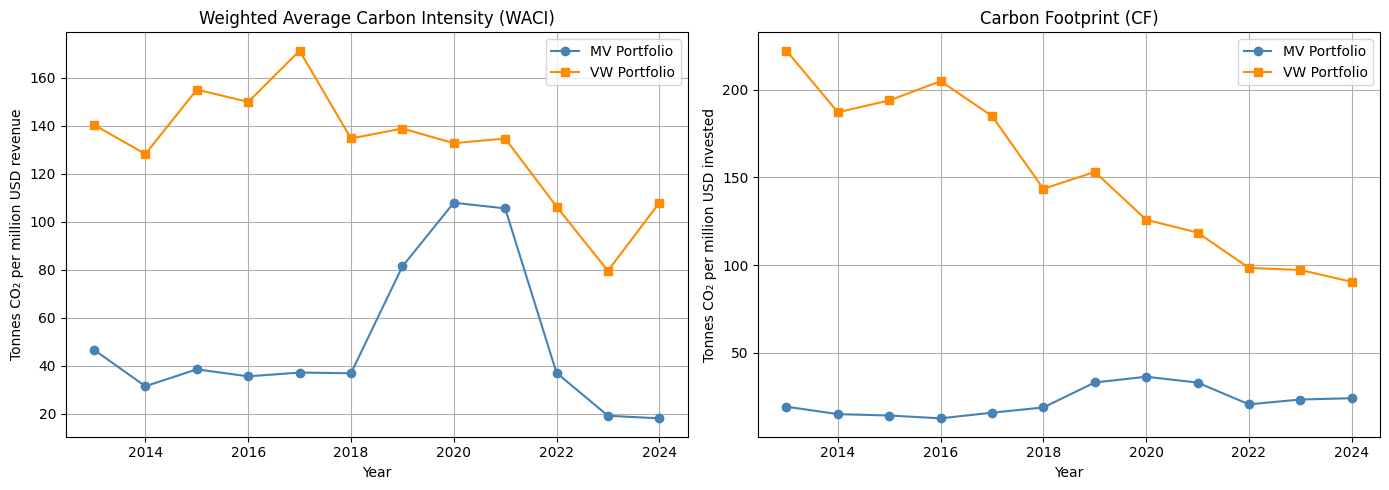

In [73]:
import os

# Create outputs folder if it doesn't exist
os.makedirs(BASE_DIR / "outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WACI
axes[0].plot(waci_mv.index, waci_mv.values, marker='o',
             label="MV Portfolio", color="steelblue")
axes[0].plot(waci_vw.index, waci_vw.values, marker='s',
             label="VW Portfolio", color="darkorange")
axes[0].set_title("Weighted Average Carbon Intensity (WACI)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Tonnes CO₂ per million USD revenue")
axes[0].legend()
axes[0].grid(True)

# Carbon Footprint
axes[1].plot(cf_mv.index, cf_mv.values, marker='o',
             label="MV Portfolio", color="steelblue")
axes[1].plot(cf_vw.index, cf_vw.values, marker='s',
             label="VW Portfolio", color="darkorange")
axes[1].set_title("Carbon Footprint (CF)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Tonnes CO₂ per million USD invested")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "carbon_metrics.png", dpi=150)
plt.show()

#### 3.1.6 Top 10 Firms Driving Carbon Intensity

We identify the firms with the highest contribution to portfolio
carbon intensity, averaged over the full sample period.
We report firm names and ISIN codes.

In [74]:
# Average CI contribution per firm across all years, weighted by MV weights
ci_contribution = {}

for year, weights in all_weights.items():
    if year not in common_years:
        continue
    ci_year = carbon_intensity[year]
    common  = weights.index.intersection(ci_year.dropna().index)
    if len(common) == 0:
        continue
    w  = weights[common]
    w  = w / w.sum()
    contrib = (w * ci_year[common])
    for isin, val in contrib.items():
        ci_contribution[isin] = ci_contribution.get(isin, []) + [val]

# Average contribution over years
avg_contrib = {isin: np.mean(vals) for isin, vals in ci_contribution.items()}
avg_contrib = pd.Series(avg_contrib).sort_values(ascending=False)

# Map ISIN to firm name — check actual column name
print("Static columns:", static.columns.tolist())  # check the exact column name

# Use whichever name appears in the print above
name_col = [c for c in static.columns if c.lower() == "name"][0]
isin_to_name = static.set_index("ISIN")[name_col].to_dict()

top10 = avg_contrib.head(10).reset_index()
top10.columns = ["ISIN", "Avg CI Contribution"]
top10["Firm Name"] = top10["ISIN"].map(isin_to_name)
top10 = top10[["Firm Name", "ISIN", "Avg CI Contribution"]]

print("\nTop 10 firms driving carbon intensity in the MV portfolio:")
print(top10.to_string(index=False))

Static columns: ['ISIN', 'NAME', 'Country', 'Region']

Top 10 firms driving carbon intensity in the MV portfolio:
                             Firm Name         ISIN  Avg CI Contribution
                            ELIA GROUP BE0003822393            14.001663
                         ICTL.HTLS.GP. GB00BHJYC057             5.136678
                     KONINKLIJKE VOPAK NL0009432491             5.092952
                         NATIONAL GRID GB00BDR05C01             3.952461
          DEVRO DEAD - DELIST.14/04/23 GB0002670437             2.703136
                         COCA-COLA HBC CH0198251305             2.508759
                                  MOWI NO0003054108             2.127780
                UNITED UTILITIES GROUP GB00B39J2M42             1.908003
        DIGNITY DEAD - DELIST.25/05/23 GB00BRB37M78             1.669844
TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1 US8816242098             1.557395


In [75]:
# Top 10 firms driving carbon intensity in the VW portfolio 
ci_contribution_vw = {}

for year in sorted(all_weights.keys()):
    if year not in common_years:
        continue
    if year not in mv_year.columns:
        continue
    if year not in carbon_intensity:
        continue

    # Align on common ISINs with valid carbon intensity and market cap
    ci_year = carbon_intensity[year].dropna()
    cap_year = mv_year[year].dropna()

    # find common ISINs
    common = cap_year.index.intersection(ci_year.index)
    if len(common) == 0:
        continue

    # Calculate VW weights for this year
    caps = cap_year[common]
    weights_vw = caps / caps.sum()

    # Calculate the contribution (VW weights * Individual Carbon Intensity)
    contrib_vw = weights_vw * ci_year[common]
    
    for isin, val in contrib_vw.items():
        ci_contribution_vw[isin] = ci_contribution_vw.get(isin, []) + [val]

# Average contribution over years for VW portfolio
avg_contrib_vw = {isin: np.mean(vals) for isin, vals in ci_contribution_vw.items()}
avg_contrib_vw = pd.Series(avg_contrib_vw).sort_values(ascending=False)

# Map ISIN to firm name for VW portfolio
top10_vw = avg_contrib_vw.head(10).reset_index()
top10_vw.columns = ["ISIN", "Avg CI Contribution"]
top10_vw["Firm Name"] = top10_vw["ISIN"].map(isin_to_name)
top10_vw = top10_vw[["Firm Name", "ISIN", "Avg CI Contribution"]]

print("\nTop 10 firms driving carbon intensity in the VW portfolio:")
print(top10_vw.to_string(index=False))


Top 10 firms driving carbon intensity in the VW portfolio:
                                   Firm Name         ISIN  Avg CI Contribution
                                      HOLCIM CH0012214059            13.806678
L AIR LQE.SC.ANYME. POUR L ETUDE ET L EPXTN. FR0000120073             7.500362
                                         RWE DE0007037129             6.167041
                        HEIDELBERG MATERIALS DE0006047004             5.675910
                                      FORTUM FI0009007132             5.430879
                                        ENEL IT0003128367             5.078611
                                   RIO TINTO GB0007188757             4.740870
                               TOTALENERGIES FR0000120271             3.165435
                                       SHELL GB00BP6MXD84             3.140855
                          CRH PUBLIC LIMITED IE0001827041             2.778739


#### 3.1.7 Save Carbon Metrics

In [76]:
# Save 
cf_mv.to_excel(CLEAN_DIR / "cf_mv.xlsx",  header=["CF_MV"])
cf_vw.to_excel(CLEAN_DIR / "cf_vw.xlsx",  header=["CF_VW"])
waci_mv.to_excel(CLEAN_DIR / "waci_mv.xlsx", header=["WACI_MV"])
waci_vw.to_excel(CLEAN_DIR / "waci_vw.xlsx", header=["WACI_VW"])

# Save emissions and carbon intensity matrices
emissions.to_excel(CLEAN_DIR / "emissions.xlsx")
carbon_intensity.to_excel(CLEAN_DIR / "carbon_intensity.xlsx")

# Save MV weights dict as a single DataFrame
weights_df = pd.DataFrame(all_weights).T  # years x ISINs
weights_df.index.name = "year"
weights_df.to_excel(CLEAN_DIR / "mv_weights.xlsx")

print("All carbon metrics saved.")

All carbon metrics saved.


#### 3.1.8 Summary
This section has computed:

- **Emissions** (Scope 1 + Scope 2) for all European firms over 2013–2024
- **Carbon Intensity (CI)** in tonnes CO₂ per million USD revenue
- **WACI** for both the MV and VW portfolios over the full sample
- **Carbon Footprint (CF)** for both portfolios over the full sample
- **Top 10 firms** contributing most to portfolio carbon intensity

Key observations:
- Compare WACI and CF levels between MV and VW
- The top 10 firms will reveal which sectors drive emissions up

These metrics feed directly into the constrained optimization in the next section.

#### 3.2 Allocation with a 50% Reduction in Carbon Emissions
This section constructs three carbon-constrained portfolios:

- **P_oos_mv(0.5)** (Section 3.2): Long-only MV portfolio with CF ≤ 50% of the unconstrained MV portfolio CF
- **P_oos_vw(0.5)** (Section 3.3): Tracking error minimization with CF ≤ 50% of the VW benchmark CF
- **P_oos_vw(NZ)** (Section 4.1): Net zero portfolio with CF reduced by 10% per year from the 2013 VW baseline

All portfolios use Scope 1 + Scope 2 emissions, European firms, annual rebalancing,
and the same investment set as the previous section.

#### 3.2.1 Rebuild Investment Universe and Base Data

In [77]:
cf_mv    = pd.read_excel(CLEAN_DIR / "cf_mv.xlsx", index_col=0).squeeze()
cf_vw    = pd.read_excel(CLEAN_DIR / "cf_vw.xlsx", index_col=0).squeeze()
emissions_df       = pd.read_excel(CLEAN_DIR / "emissions.xlsx", index_col=0)
carbon_intensity   = pd.read_excel(CLEAN_DIR / "carbon_intensity.xlsx", index_col=0)
emissions_df.columns      = emissions_df.columns.astype(int)
carbon_intensity.columns  = carbon_intensity.columns.astype(int)

cf_mv.index = cf_mv.index.astype(int)
cf_vw.index = cf_vw.index.astype(int)

print("cf_mv loaded:", cf_mv.shape)
print("cf_vw loaded:", cf_vw.shape)
print("emissions loaded:", emissions_df.shape)

cf_mv loaded: (12,)
cf_vw loaded: (12,)
emissions loaded: (618, 26)


In [78]:
# Filter to Europe
static_europe = static[static["Region"].str.upper() == "EUR"].copy()
isins_europe  = set(static_europe["ISIN"])

# Build returns matrix
returns_matrix = returns_raw[returns_raw["ISIN"].isin(isins_europe)].copy()
returns_matrix = returns_matrix.set_index("ISIN").drop(columns=["NAME"])
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix = returns_matrix.sort_index(axis=1)

# Build mv_year and mv_month matrices
mv_year = mv_year_clean[mv_year_clean["ISIN"].isin(isins_europe)].copy()
mv_year = mv_year.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
mv_year.columns = mv_year.columns.astype(int)

mv_matrix = mv_month_clean[mv_month_clean["ISIN"].isin(isins_europe)].copy()
mv_matrix = mv_matrix.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
mv_matrix.columns = pd.to_datetime(mv_matrix.columns)
mv_matrix = mv_matrix.sort_index(axis=1)

# Carbon data
isins_scope1 = set(scope1_clean["ISIN"])
isins_scope2 = set(scope2_clean["ISIN"])
has_carbon_global = pd.Series(
    returns_matrix.index.isin(isins_scope1 | isins_scope2),
    index=returns_matrix.index
)

# Pre-compute e_over_cap for all years
e_over_cap_all = {}
for year in range(2013, 2025):
    if year in emissions_df.columns and year in mv_year.columns:
        e_over_cap_all[year] = emissions_df[year].div(mv_year[year].replace(0, np.nan))

# VW weights for tracking error (annual, end of year)
vw_weights_annual = {}
for year in range(2013, 2025):
    if year not in mv_year.columns:
        continue
    caps = mv_year[year].dropna()
    caps = caps[caps > 0]
    vw_weights_annual[year] = caps / caps.sum()

print("Data ready.")
print(f"Returns matrix: {returns_matrix.shape}")

Data ready.
Returns matrix: (633, 314)


#### 3.2.2 Helper Functions
We define reusable functions for:
- Building the per-year investment set
- Computing the carbon footprint constraint vector
- Running the monthly weight-drift return simulation

In [79]:
def get_investment_set(year, returns_matrix, past_cols, has_carbon_global,
                       e_over_cap_all, emissions_df, mv_year, window=120):
    """Return valid ISINs for a given year after applying all filters."""
    past_ret = returns_matrix[past_cols]

    enough_obs    = past_ret.notna().sum(axis=1) >= 36
    non_nan_count = past_ret.notna().sum(axis=1).replace(0, np.nan)
    zero_count    = (past_ret == 0).sum(axis=1)
    not_stale     = (zero_count / non_nan_count) <= 0.5
    has_price     = past_ret[past_cols[-1]].notna()
    has_carbon    = has_carbon_global

    valid       = enough_obs & not_stale & has_price & has_carbon
    valid_isins = valid[valid].index.tolist()

    if year in e_over_cap_all:
        e_over_cap_y = e_over_cap_all[year]
        cap_year_vw  = mv_year[year].dropna()
        e_year_vw    = emissions_df[year].dropna()
        common_vw    = cap_year_vw.index.intersection(e_year_vw.index)
        if len(common_vw) > 0:
            cf_vw_year = e_year_vw[common_vw].sum() / cap_year_vw[common_vw].sum()
            threshold  = 3 * cf_vw_year
        else:
            threshold  = e_over_cap_y.quantile(0.95)
        e_valid     = e_over_cap_y.reindex(valid_isins).dropna()
        valid_isins = [i for i in valid_isins if
                       i not in e_valid.index or e_over_cap_y.get(i, 0) <= threshold]

    return valid_isins


def get_cf_vector(valid_isins, year, emissions_df, mv_year):
    """Return E_i/Cap_i vector for valid ISINs in a given year."""
    e_year   = emissions_df[year]
    cap_year = mv_year[year]
    e_over_cap = e_year.div(cap_year.replace(0, np.nan))
    e_over_cap = e_over_cap.reindex(valid_isins).fillna(0)
    return e_over_cap.values


def simulate_returns(w, valid_isins, returns_matrix, end_date):
    """Simulate next-year monthly returns with weight drift."""
    next_cols = returns_matrix.columns[
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]
    if len(next_cols) == 0:
        return [], []

    next_ret  = returns_matrix.loc[valid_isins, next_cols].fillna(0).values
    w_current = w.copy()
    rets, dates = [], []

    for k in range(next_ret.shape[1]):
        r_t       = next_ret[:, k]
        rp_t      = float(w_current @ r_t)
        rets.append(rp_t)
        dates.append(next_cols[k])
        w_current = w_current * (1 + r_t)
        total     = w_current.sum()
        if total > 0:
            w_current = w_current / total

    return rets, dates


def compute_stats(returns_series, rf_annual=rf_monthly * 12):
    """Compute annualized performance statistics."""
    rf_monthly  = rf_annual / 12
    mean_annual = returns_series.mean() * 12
    vol_annual  = returns_series.std() * np.sqrt(12)
    sharpe      = ((returns_series - rf_monthly).mean() / returns_series.std()) * np.sqrt(12)
    return {
        "Annualized Return":     round(mean_annual, 4),
        "Annualized Volatility": round(vol_annual, 4),
        "Sharpe Ratio":          round(sharpe, 4),
        "Min Monthly Return":    round(returns_series.min(), 4),
        "Max Monthly Return":    round(returns_series.max(), 4)
    }

#### 3.2.3 MV Portfolio with 50% CF Constraint: P_oos_mv(0.5)

We solve each year:

min  αᵀ Σ α  
s.t. Σᵢ αᵢ × (Eᵢ/Capᵢ) ≤ 0.5 × CF_mv(Y)  
     Σᵢ αᵢ = 1  
     αᵢ ≥ 0, αᵢ ≤ 0.05

where CF_mv(Y) is the carbon footprint of the unconstrained MV portfolio in year Y.

In [80]:
start_year = 2013
end_year   = 2024
window     = 120

mv05_returns_list = []
mv05_dates_list   = []
mv05_weights      = {}
mv05_cf           = {}

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue
    if year not in cf_mv.index:
        continue

    valid_isins = get_investment_set(
        year, returns_matrix, past_cols, has_carbon_global,
        e_over_cap_all, emissions_df, mv_year
    )

    if len(valid_isins) < 10:
        continue

    sub        = returns_matrix[past_cols].loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    # Carbon footprint constraint vector
    cf_vec      = get_cf_vector(valid_isins, year, emissions_df, mv_year)
    cf_target   = 0.5 * cf_mv[year]

    def portfolio_variance(w):
        return w @ Sigma @ w

    def portfolio_variance_grad(w):
        return 2 * Sigma @ w

    constraints = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1,
                         'jac': lambda w: np.ones(N)},
        {'type': 'ineq','fun': lambda w: cf_target - cf_vec @ w,
                         'jac': lambda w: -cf_vec}
    ]
    bounds = [(0, 0.05)] * N
    w0     = np.ones(N) / N

    result = minimize(
        portfolio_variance, w0,
        jac=portfolio_variance_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: P_mv(0.5) optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    mv05_weights[year] = pd.Series(w, index=valid_isins)
    mv05_cf[year]      = float(cf_vec @ w)

    rets, dates = simulate_returns(w, valid_isins, returns_matrix, end_date)
    mv05_returns_list.extend(rets)
    mv05_dates_list.extend(dates)

    print(f"Year {year}: CF = {mv05_cf[year]:.2f} (target ≤ {cf_target:.2f})")

mv05_returns = pd.Series(mv05_returns_list, index=mv05_dates_list).sort_index()
print(f"\nP_mv(0.5) returns shape: {mv05_returns.shape}")

Year 2013: CF = 9.68 (target ≤ 9.68)
Year 2014: CF = 7.57 (target ≤ 7.57)
Year 2015: CF = 7.17 (target ≤ 7.17)
Year 2016: CF = 6.36 (target ≤ 6.36)
Year 2017: CF = 7.98 (target ≤ 7.98)
Year 2018: CF = 9.47 (target ≤ 9.47)
Year 2019: CF = 16.58 (target ≤ 16.58)
Year 2020: CF = 18.22 (target ≤ 18.22)
Year 2021: CF = 16.55 (target ≤ 16.55)
Year 2022: CF = 10.35 (target ≤ 10.35)
Year 2023: CF = 11.73 (target ≤ 11.73)
Year 2024: CF = 12.11 (target ≤ 12.11)

P_mv(0.5) returns shape: (144,)


#### 3.2.4 Tracking Error Minimization with 50% CF Constraint: P_oos_vw(0.5)

We solve each year:

min  (α - α_vw)ᵀ Σ (α - α_vw)  
s.t. Σᵢ αᵢ × (Eᵢ/Capᵢ) ≤ 0.5 × CF_vw(Y)  
     Σᵢ αᵢ = 1  
     αᵢ ≥ 0, αᵢ ≤ 0.05

where α_vw are the value-weighted benchmark weights and CF_vw(Y) is the VW carbon footprint in year Y.

In [81]:
vw05_returns_list = []
vw05_dates_list   = []
vw05_weights      = {}
vw05_cf           = {}

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue
    if year not in cf_vw.index:
        continue

    valid_isins = get_investment_set(
        year, returns_matrix, past_cols, has_carbon_global,
        e_over_cap_all, emissions_df, mv_year
    )

    if len(valid_isins) < 10:
        continue

    sub        = returns_matrix[past_cols].loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    # VW benchmark weights aligned to valid_isins
    vw_w = vw_weights_annual.get(year, pd.Series(dtype=float))
    vw_w = vw_w.reindex(valid_isins).fillna(0)
    vw_w = vw_w / vw_w.sum() if vw_w.sum() > 0 else pd.Series(np.ones(N)/N, index=valid_isins)
    w_vw = vw_w.values

    # Carbon footprint constraint
    cf_vec    = get_cf_vector(valid_isins, year, emissions_df, mv_year)
    cf_target = 0.5 * cf_vw[year]

    def tracking_error(w):
        diff = w - w_vw
        return diff @ Sigma @ diff

    def tracking_error_grad(w):
        return 2 * Sigma @ (w - w_vw)

    constraints = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1,
                         'jac': lambda w: np.ones(N)},
        {'type': 'ineq','fun': lambda w: cf_target - cf_vec @ w,
                         'jac': lambda w: -cf_vec}
    ]
    bounds = [(0, 0.05)] * N
    w0     = w_vw.copy()

    result = minimize(
        tracking_error, w0,
        jac=tracking_error_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: P_vw(0.5) optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    vw05_weights[year] = pd.Series(w, index=valid_isins)
    vw05_cf[year]      = float(cf_vec @ w)

    rets, dates = simulate_returns(w, valid_isins, returns_matrix, end_date)
    vw05_returns_list.extend(rets)
    vw05_dates_list.extend(dates)

    print(f"Year {year}: CF = {vw05_cf[year]:.2f} (target ≤ {cf_target:.2f})")

vw05_returns = pd.Series(vw05_returns_list, index=vw05_dates_list).sort_index()
print(f"\nP_vw(0.5) returns shape: {vw05_returns.shape}")

Year 2013: CF = 72.12 (target ≤ 111.12)
Year 2014: CF = 52.74 (target ≤ 93.57)
Year 2015: CF = 50.56 (target ≤ 96.95)
Year 2016: CF = 43.97 (target ≤ 102.44)
Year 2017: CF = 53.59 (target ≤ 92.50)
Year 2018: CF = 40.58 (target ≤ 71.76)
Year 2019: CF = 43.88 (target ≤ 76.58)
Year 2020: CF = 33.96 (target ≤ 62.95)
Year 2021: CF = 28.52 (target ≤ 59.29)
Year 2022: CF = 29.97 (target ≤ 49.22)
Year 2023: CF = 31.13 (target ≤ 48.64)
Year 2024: CF = 20.89 (target ≤ 45.27)

P_vw(0.5) returns shape: (144,)


#### 3.2.5 Comparison: P_mv vs P_mv(0.5) and P_vw vs P_vw(0.5)

In [82]:
# Load base portfolio returns from previous section for comparison
mv_returns_base = pd.read_excel(CLEAN_DIR / "mv_returns.xlsx", index_col=0).squeeze()
vw_returns_base = pd.read_excel(CLEAN_DIR / "vw_returns.xlsx", index_col=0).squeeze()
mv_returns_base.index = pd.to_datetime(mv_returns_base.index)
vw_returns_base.index = pd.to_datetime(vw_returns_base.index)

# Align all to common OOS dates
common_mv = mv_returns_base.index.intersection(mv05_returns.index)
common_vw = vw_returns_base.index.intersection(vw05_returns.index)

# Statistics table
stats = pd.DataFrame({
    "P_mv":      compute_stats(mv_returns_base.loc[common_mv]),
    "P_mv(0.5)": compute_stats(mv05_returns.loc[common_mv]),
    "P_vw":      compute_stats(vw_returns_base.loc[common_vw]),
    "P_vw(0.5)": compute_stats(vw05_returns.loc[common_vw])
}).T

print("=== Portfolio Performance Comparison ===")
print(stats.to_string())

=== Portfolio Performance Comparison ===
           Annualized Return  Annualized Volatility  Sharpe Ratio  Min Monthly Return  Max Monthly Return
P_mv                  0.0646                 0.1290        0.3645             -0.1209              0.1335
P_mv(0.5)             0.0725                 0.1257        0.4372             -0.1223              0.1363
P_vw                  0.0858                 0.1587        0.4299             -0.1536              0.1822
P_vw(0.5)             0.0826                 0.1597        0.4072             -0.1542              0.1822


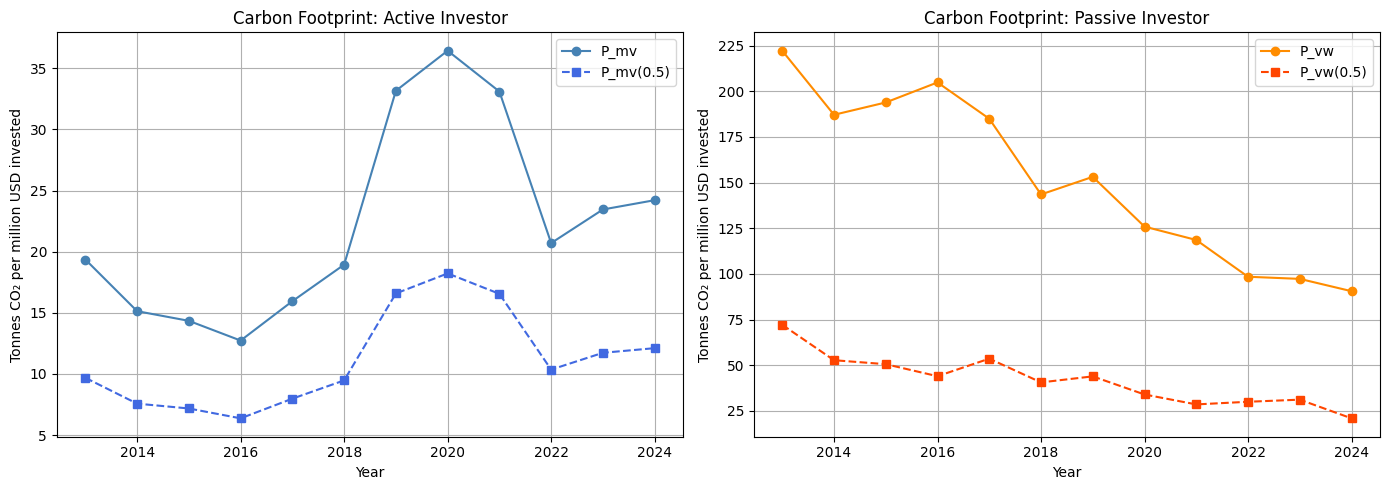

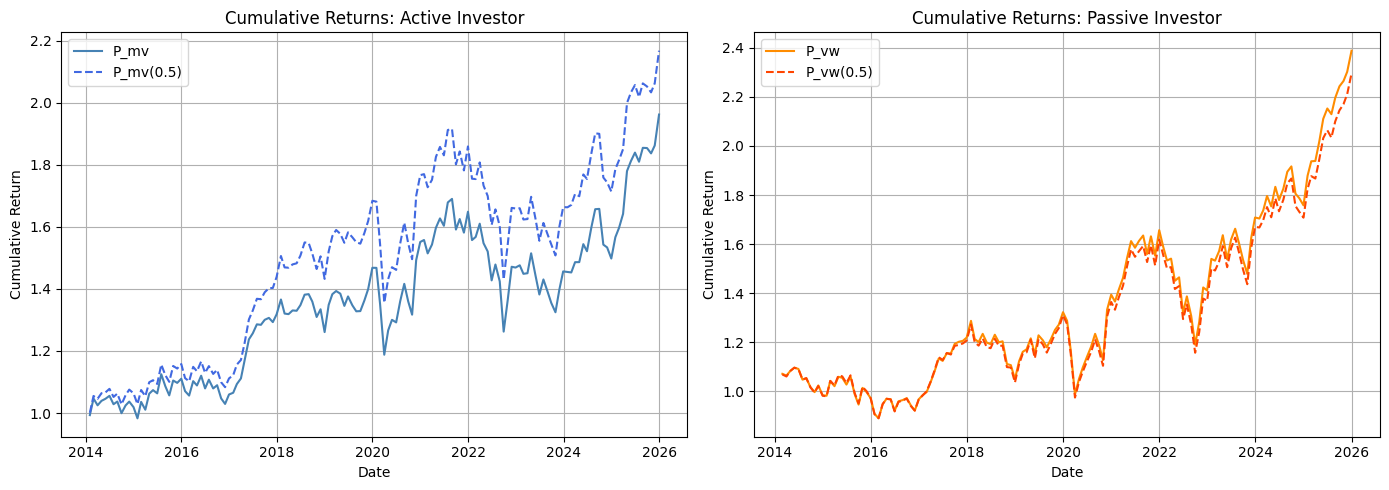

In [83]:
# Carbon footprint comparison
mv05_cf_series = pd.Series(mv05_cf).sort_index()
vw05_cf_series = pd.Series(vw05_cf).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Active investor comparison
axes[0].plot(cf_mv.index, cf_mv.values, marker='o', label="P_mv", color="steelblue")
axes[0].plot(mv05_cf_series.index, mv05_cf_series.values, marker='s',
             label="P_mv(0.5)", color="royalblue", linestyle='--')
axes[0].set_title("Carbon Footprint: Active Investor")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Tonnes CO₂ per million USD invested")
axes[0].legend()
axes[0].grid(True)

# Passive investor comparison
axes[1].plot(cf_vw.index, cf_vw.values, marker='o', label="P_vw", color="darkorange")
axes[1].plot(vw05_cf_series.index, vw05_cf_series.values, marker='s',
             label="P_vw(0.5)", color="orangered", linestyle='--')
axes[1].set_title("Carbon Footprint: Passive Investor")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Tonnes CO₂ per million USD invested")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "carbon_footprint_comparison.png", dpi=150)
plt.show()

# Cumulative returns comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_mv     = (1 + mv_returns_base.loc[common_mv]).cumprod()
cum_mv05   = (1 + mv05_returns.loc[common_mv]).cumprod()
cum_vw     = (1 + vw_returns_base.loc[common_vw]).cumprod()
cum_vw05   = (1 + vw05_returns.loc[common_vw]).cumprod()

axes[0].plot(cum_mv.index, cum_mv.values, label="P_mv", color="steelblue")
axes[0].plot(cum_mv05.index, cum_mv05.values, label="P_mv(0.5)", color="royalblue", linestyle='--')
axes[0].set_title("Cumulative Returns: Active Investor")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cum_vw.index, cum_vw.values, label="P_vw", color="darkorange")
axes[1].plot(cum_vw05.index, cum_vw05.values, label="P_vw(0.5)", color="orangered", linestyle='--')
axes[1].set_title("Cumulative Returns: Passive Investor")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "cumulative_returns_comparison.png", dpi=150)
plt.show()

#### 3.2.6 Net Zero Portfolio: P_oos_vw(NZ)

We implement a 10% annual carbon reduction from the 2013 VW baseline:

CF(p)_Y ≤ (1 - 0.10)^(Y - 2013) × CF_vw(2013)

for Y = 2013, ..., 2024.

The optimization is the same tracking error minimization as Section 3.3,
but with a tightening carbon constraint each year.

In [84]:
theta    = 0.10
Y0       = 2013
cf_vw_Y0 = cf_vw[Y0]  # baseline VW CF in 2013

nz_returns_list = []
nz_dates_list   = []
nz_weights      = {}
nz_cf           = {}
nz_targets      = {}

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue

    # Net zero target for year Y
    cf_target = (1 - theta) ** (year - Y0 + 1) * cf_vw_Y0
    nz_targets[year] = cf_target

    valid_isins = get_investment_set(
        year, returns_matrix, past_cols, has_carbon_global,
        e_over_cap_all, emissions_df, mv_year
    )

    if len(valid_isins) < 10:
        continue

    sub        = returns_matrix[past_cols].loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    # VW benchmark weights aligned to valid_isins
    vw_w = vw_weights_annual.get(year, pd.Series(dtype=float))
    vw_w = vw_w.reindex(valid_isins).fillna(0)
    vw_w = vw_w / vw_w.sum() if vw_w.sum() > 0 else pd.Series(np.ones(N)/N, index=valid_isins)
    w_vw = vw_w.values

    cf_vec = get_cf_vector(valid_isins, year, emissions_df, mv_year)

    def tracking_error(w):
        diff = w - w_vw
        return diff @ Sigma @ diff

    def tracking_error_grad(w):
        return 2 * Sigma @ (w - w_vw)

    constraints = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1,
                         'jac': lambda w: np.ones(N)},
        {'type': 'ineq','fun': lambda w: cf_target - cf_vec @ w,
                         'jac': lambda w: -cf_vec}
    ]
    bounds = [(0, 0.05)] * N
    w0     = w_vw.copy()

    result = minimize(
        tracking_error, w0,
        jac=tracking_error_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: P_vw(NZ) optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    nz_weights[year] = pd.Series(w, index=valid_isins)
    nz_cf[year]      = float(cf_vec @ w)

    rets, dates = simulate_returns(w, valid_isins, returns_matrix, end_date)
    nz_returns_list.extend(rets)
    nz_dates_list.extend(dates)

    print(f"Year {year}: CF = {nz_cf[year]:.2f} (target ≤ {cf_target:.2f})")

nz_returns = pd.Series(nz_returns_list, index=nz_dates_list).sort_index()
print(f"\nP_vw(NZ) returns shape: {nz_returns.shape}")

Year 2013: CF = 72.12 (target ≤ 200.02)
Year 2014: CF = 52.74 (target ≤ 180.02)
Year 2015: CF = 50.56 (target ≤ 162.02)
Year 2016: CF = 43.97 (target ≤ 145.81)
Year 2017: CF = 53.59 (target ≤ 131.23)
Year 2018: CF = 40.58 (target ≤ 118.11)
Year 2019: CF = 43.88 (target ≤ 106.30)
Year 2020: CF = 33.96 (target ≤ 95.67)
Year 2021: CF = 28.52 (target ≤ 86.10)
Year 2022: CF = 29.97 (target ≤ 77.49)
Year 2023: CF = 31.13 (target ≤ 69.74)
Year 2024: CF = 20.89 (target ≤ 62.77)

P_vw(NZ) returns shape: (144,)


#### 3.2.7 Comparison: P_vw vs P_vw(0.5) vs P_vw(NZ)

In [85]:
# Align to common dates
common_all = vw_returns_base.index.intersection(vw05_returns.index).intersection(nz_returns.index)

stats_passive = pd.DataFrame({
    "P_vw":      compute_stats(vw_returns_base.loc[common_all]),
    "P_vw(0.5)": compute_stats(vw05_returns.loc[common_all]),
    "P_vw(NZ)":  compute_stats(nz_returns.loc[common_all])
}).T

print("=== Passive Investor Portfolio Comparison ===")
print(stats_passive.to_string())

=== Passive Investor Portfolio Comparison ===
           Annualized Return  Annualized Volatility  Sharpe Ratio  Min Monthly Return  Max Monthly Return
P_vw                  0.0858                 0.1587        0.4299             -0.1536              0.1822
P_vw(0.5)             0.0826                 0.1597        0.4072             -0.1542              0.1822
P_vw(NZ)              0.0826                 0.1597        0.4072             -0.1542              0.1822


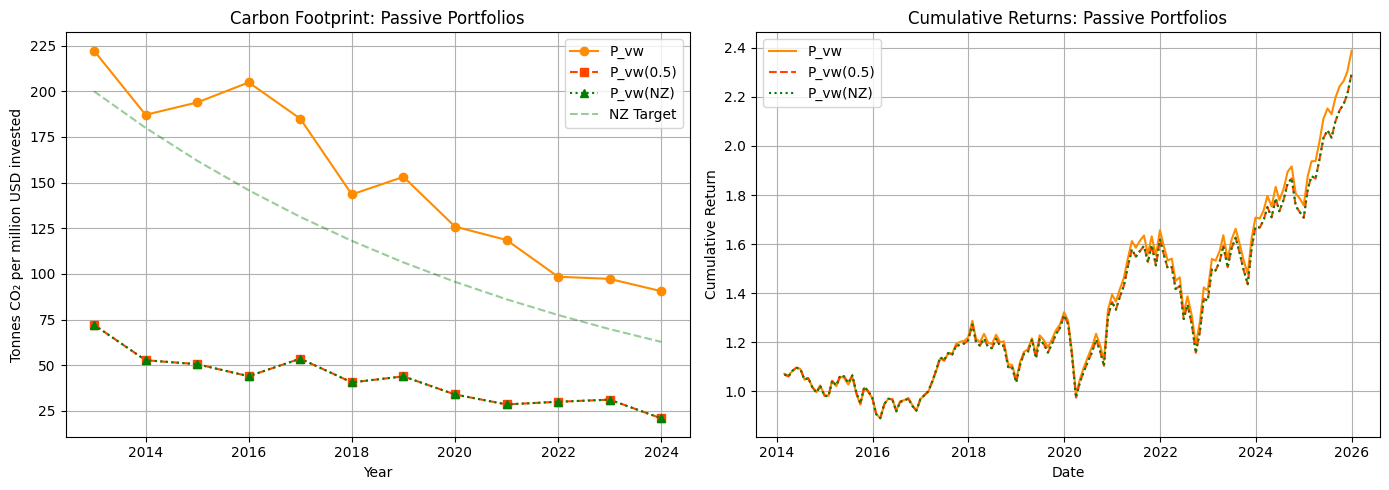

In [86]:
# Carbon footprint: P_vw vs P_vw(0.5) vs P_vw(NZ)
nz_cf_series      = pd.Series(nz_cf).sort_index()
nz_targets_series = pd.Series(nz_targets).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Carbon footprint
axes[0].plot(cf_vw.index, cf_vw.values, marker='o',
             label="P_vw", color="darkorange")
axes[0].plot(vw05_cf_series.index, vw05_cf_series.values, marker='s',
             label="P_vw(0.5)", color="orangered", linestyle='--')
axes[0].plot(nz_cf_series.index, nz_cf_series.values, marker='^',
             label="P_vw(NZ)", color="green", linestyle=':')
axes[0].plot(nz_targets_series.index, nz_targets_series.values,
             label="NZ Target", color="green", linestyle='--', alpha=0.4)
axes[0].set_title("Carbon Footprint: Passive Portfolios")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Tonnes CO₂ per million USD invested")
axes[0].legend()
axes[0].grid(True)

# Cumulative returns
cum_vw_all   = (1 + vw_returns_base.loc[common_all]).cumprod()
cum_vw05_all = (1 + vw05_returns.loc[common_all]).cumprod()
cum_nz       = (1 + nz_returns.loc[common_all]).cumprod()

axes[1].plot(cum_vw_all.index, cum_vw_all.values,
             label="P_vw", color="darkorange")
axes[1].plot(cum_vw05_all.index, cum_vw05_all.values,
             label="P_vw(0.5)", color="orangered", linestyle='--')
axes[1].plot(cum_nz.index, cum_nz.values,
             label="P_vw(NZ)", color="green", linestyle=':')
axes[1].set_title("Cumulative Returns: Passive Portfolios")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "passive_portfolios_comparison.png", dpi=150)
plt.show()

#### 3.2.8 Summary Table of all Portfolios

In [87]:
# Full summary of all 5 portfolios
common_final = (mv_returns_base.index
                .intersection(mv05_returns.index)
                .intersection(vw_returns_base.index)
                .intersection(vw05_returns.index)
                .intersection(nz_returns.index))

stats_all = pd.DataFrame({
    "P_mv":      compute_stats(mv_returns_base.loc[common_final]),
    "P_mv(0.5)": compute_stats(mv05_returns.loc[common_final]),
    "P_vw":      compute_stats(vw_returns_base.loc[common_final]),
    "P_vw(0.5)": compute_stats(vw05_returns.loc[common_final]),
    "P_vw(NZ)":  compute_stats(nz_returns.loc[common_final])
}).T

print("=== Full Portfolio Summary ===")
print(stats_all.to_string())

=== Full Portfolio Summary ===
           Annualized Return  Annualized Volatility  Sharpe Ratio  Min Monthly Return  Max Monthly Return
P_mv                  0.0656                 0.1294        0.3713             -0.1209              0.1335
P_mv(0.5)             0.0729                 0.1261        0.4391             -0.1223              0.1363
P_vw                  0.0858                 0.1587        0.4299             -0.1536              0.1822
P_vw(0.5)             0.0826                 0.1597        0.4072             -0.1542              0.1822
P_vw(NZ)              0.0826                 0.1597        0.4072             -0.1542              0.1822


#### 3.2.9 Key Takeaways

- **P_mv(0.5)** imposes a 50% CF reduction on the already low-carbon MV portfolio.
  The constraint is binding and may push the optimizer toward different sectors.

- **P_vw(0.5)** stays close to the market benchmark while halving its carbon footprint.
  The tracking error cost tells us how much we "pay" in terms of deviation from the market.

- **P_vw(NZ)** implements a cumulative 10% annual reduction path starting from the 2013
  VW baseline. In later years the constraint becomes very tight and may be infeasible
  for some firms, reflecting the real difficulty of achieving net zero.

- The financial cost of decarbonization (reduction in Sharpe ratio or return) should be
  compared across portfolios to evaluate the trade-off between financial performance
  and climate impact.